## Simple MultiAiAgent Architecture

In [1]:
import os
from typing import Annotated, List, Literal, Dict, Any
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv
from langchain.agents import create_agent
load_dotenv()
from langchain_tavily import TavilySearch
from langgraph.types import Command, interrupt
from datetime import datetime
import random

c:\Users\Deepam Dey\Desktop\LanGraph chatbot\venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
c:\Users\Deepam Dey\Desktop\LanGraph chatbot\venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [2]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [3]:
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [4]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_agent:str # which agent should go next

@tool
def search_web(query:str)-> str:
    """ Search the web for the information."""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content:str)-> str:
    """ Write summary of the provided content."""
    summary = f"Summary of findings:\n\n{content[:500]}...."
    
    return str(summary)

In [5]:
# Define the agent function
def researcher_agent(state: AgentState):
    """ Researcher agent that searches for information"""
    messages = state['messages']
    system_message = SystemMessage(content="You are a research assistant. Use the search_web tool to find the user's request.")

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_message] + messages)

    return {
        "messages": [response],
        "next_agent": "writer"
    }

def writer_agent(state: AgentState):
    """ Writer agent that creates summaries"""
    messages = state['messages']
    system_message = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

    response = llm.invoke([system_message] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

In [6]:
# tool execulor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state['messages']
    last_message = messages[-1]
    # check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    return state

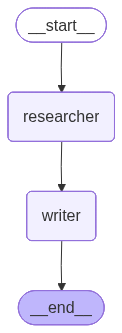

In [7]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)

final_workflow = workflow.compile()
final_workflow

In [8]:
response = final_workflow.invoke({"messages": "Research about the usecase of agentic ai in business"})
response['messages'][-1].content

" \n\nAfter conducting research, here's a summary of the findings:\n\n**What is Agentic AI?**\n\nAgentic AI refers to artificial intelligence (AI) that exhibits autonomous, goal-oriented behavior, reminiscent of human agency. It involves AI systems that can learn, adapt, and interact with their environment in a way that is similar to human decision-making.\n\n**Business Use Cases for Agentic AI:**\n\n1. **Predictive Maintenance**: Agentic AI can analyze equipment performance data to predict when maintenance is required, reducing downtime and increasing overall equipment effectiveness.\n2. **Supply Chain Optimization**: Agentic AI can optimize inventory levels, manage logistics, and predict demand to minimize costs and improve efficiency.\n3. **Customer Service**: Agentic AI-powered chatbots can engage with customers, provide personalized support, and route complex issues to human agents.\n4. **Marketing Automation**: Agentic AI can analyze customer behavior, preferences, and demographi

## Supervised MultiAIAgent Architecture

In [9]:
class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [10]:
from langchain_core.prompts import ChatPromptTemplate

def create_supervisor_chain(llm):
    """Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """You are a supervisor managing a team of agents:

1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""
            ),
            ("human", "{task}")
        ]
    )

    return supervisor_prompt | llm


In [11]:
from typing import Dict
from langchain_core.messages import AIMessage

def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""

    messages = state["messages"]
    task = messages[-1].content if messages else "No task"

    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_supervisor_chain(llm)
    decision = chain.invoke(
        {
            "task": task,
            "has_research": has_research,
            "has_analysis": has_analysis,
            "has_report": has_report,
        }
    )

    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)

    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📘 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📊 Supervisor: Research done. Time for analysis! Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📝 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task,
    }


In [12]:
def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt
    writing_prompt = f"""
As a professional writer, create an executive report based on:

Task:
{task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise.
"""

    # Get report from LLM
    report_response = llm.invoke(
        [HumanMessage(content=writing_prompt)]
    )
    report = report_response.content

    # Create final formatted report
    final_report = f"""
FINAL REPORT
{'=' * 50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'=' * 50}

{report}

{'=' * 50}
Report compiled by Multi-Agent AI System powered by Groq
"""

    return {
        "messages": [
            AIMessage(
                content="✍️ Writer: Report complete! See below for the full document."
            )
        ],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }


In [13]:
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""

    task = state.get("current_task", "research topic")

    # Create research prompt
    research_prompt = f"""
As a research specialist, provide comprehensive information about: {task}

Include:
1. Key facts and background
2. Current trends or developments
3. Important statistics or data points
4. Notable examples or case studies

Be concise but thorough.
"""

    # Get research from LLM
    research_response = llm.invoke(
        [HumanMessage(content=research_prompt)]
    )
    research_data = research_response.content

    # Create agent message
    agent_message = (
        f"🔍 Researcher: I've completed the research on '{task}'.\n\n"
        f"Key findings:\n{research_data[:800]}"
    )

    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor",
    }


In [14]:
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "")

    # Create analysis prompt
    analysis_prompt = f"""
As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}
"""

    # Get analysis from LLM
    analysis_response = llm.invoke(
        [HumanMessage(content=analysis_prompt)]
    )
    analysis = analysis_response.content

    # Create agent message
    agent_message = (
        f"Analyst: I've completed the analysis.\n\n"
        f"Top insights:\n{analysis[:400]}..."
    )

    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor",
    }


In [15]:

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""

    next_agent = state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent

    return "supervisor"


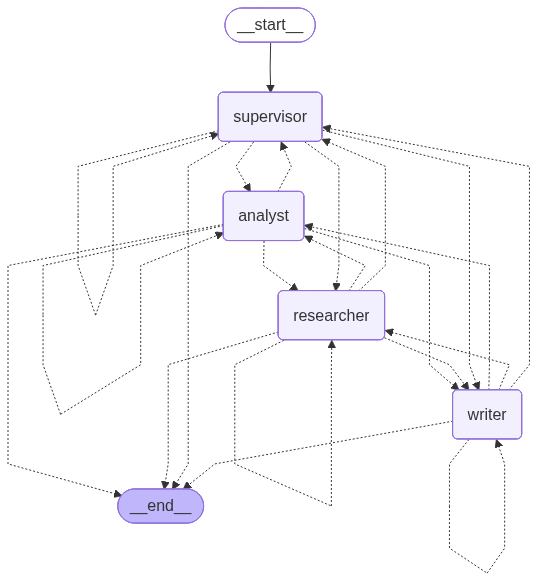

In [16]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END,
        },
    )

# Compile workflow
final_workflow = workflow.compile()
final_workflow

In [17]:
final_workflow.invoke(HumanMessage(content="what are the benefits and risks of AI in healthcare?"))

researcher
analyst
writer


{'messages': [AIMessage(content="📘 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='876562f5-a8c2-4b91-8a92-6a511f1451cb'),
  AIMessage(content='🔍 Researcher: I\'ve completed the research on \'No task\'.\n\nKey findings:\nSince "no task" was specified, I\'ll provide a general framework for a research report. However, I\'ll choose a topic to fill in the sections. Let\'s take "Vertical Farming" as an example.\n\n**Topic: Vertical Farming**\n\n**1. Key Facts and Background:**\n\n- Definition: Vertical farming is an agricultural method where crops are grown in vertically stacked layers, usually in an indoor environment.\n- Origins: The concept of vertical farming dates back to the 19th century, but modern vertical farming began to take shape in the 1990s.\n- Purpose: To increase crop yields, reduce water and land usage, and improve food security.\n- Key characteristics: Hydroponics, LED lighting, climate control, and precis

User Task
   ↓
Supervisor Agent (decision maker)
   ↓
Researcher → Analyst → Writer
   ↑        ↑          ↓
   └────── Router ─────┘
          (state-based)
              ↓
             END


MULTI-AGENT WORKFLOW EXPLANATION

This project implements a supervisor-driven multi-agent system using LangGraph.

1. Shared State (SupervisorState)
   - Acts as a central memory for all agents.
   - Stores messages, task context, intermediate outputs (research, analysis),
     final report, routing decision, and completion flag.
   - Enables stateful, non-linear agent execution.

2. Supervisor Agent
   - Orchestrator of the system.
   - Reads the current state and conversation.
   - Uses an LLM to decide which agent should run next
     (researcher / analyst / writer / end).
   - Writes the decision to `next_agent`.

3. Researcher Agent
   - Gathers raw information about the task.
   - Produces factual data, trends, statistics, and examples.
   - Saves output to `research_data` and returns control to supervisor.

4. Analyst Agent
   - Consumes `research_data`.
   - Performs reasoning, pattern detection, and insight generation.
   - Writes results to `analysis` and routes back to supervisor.

5. Writer Agent
   - Synthesizes research and analysis into a structured final report.
   - Generates executive summary, findings, insights, and recommendations.
   - Writes `final_report` and sets `task_complete = True`.

6. Router
   - Deterministic control mechanism.
   - Routes execution based on `next_agent` or ends the workflow if
     `task_complete` is True.
   - Prevents LLM hallucinated control flow.

7. LangGraph Workflow
   - Connects all agents as nodes in a dynamic graph.
   - Uses conditional edges to enable flexible, state-driven routing.
   - Cleanly terminates when the task is complete.

Key Idea:
Decision-making is handled by the supervisor LLM,
execution is handled by specialized agents,
and control flow is enforced by the router.


## Hierarchical Multi AI Agent Architechure

In [18]:
class HierarchicalState(MessagesState):
    next_agent: str
    current_task: str

    research_data: str
    market_data: str
    analysis: str

    technical_report: str
    summary_report: str
    final_report: str

    task_complete: bool = False


In [19]:
def ceo_agent(state: HierarchicalState):
    """Decides whether Research Team or Writing Team should work next"""

    if not state.get("research_data"):
        next_agent = "research_lead"
        msg = "CEO: Assigning task to Research Team."
    elif not state.get("final_report"):
        next_agent = "writing_lead"
        msg = "CEO: Assigning task to Writing Team."
    else:
        next_agent = "end"
        msg = "CEO: Task complete."

    return {
        "messages": [AIMessage(content=msg)],
        "next_agent": next_agent
    }


In [20]:
def research_lead_agent(state: HierarchicalState):
    if not state.get("market_data"):
        next_agent = "market_researcher"

    elif not state.get("research_data"):
        next_agent = "data_researcher"

    else:
        next_agent = "ceo" 

    return {
        "messages": [AIMessage(content="Research Lead: Assigning researcher.")],
        "next_agent": next_agent
    }


def market_researcher(state: HierarchicalState):
    response = llm.invoke([
        HumanMessage(content=f"Provide market trends and competitor analysis for {state.get('current_task')}")
    ])

    return {
        "market_data": response.content,
        "messages": [AIMessage(content="Market Research completed.")],
        "next_agent": "research_lead"
    }


def data_researcher(state: HierarchicalState):
    response = llm.invoke([
        HumanMessage(content=f"Provide technical and statistical data about {state.get('current_task')}")
    ])

    return {
        "research_data": response.content,
        "messages": [AIMessage(content="Data Research completed.")],
        "next_agent": "research_lead"
    }



In [21]:
def writing_lead_agent(state: HierarchicalState):

    if not state.get("technical_report"):
        next_agent = "technical_writer"

    elif not state.get("summary_report"):
        next_agent = "summary_writer"

    else:
        final_report = f"""
EXECUTIVE SUMMARY
-----------------
{state['summary_report']}

FULL TECHNICAL REPORT
---------------------
{state['technical_report']}
"""

        return {
            "final_report": final_report,
            "task_complete": True,   # STOP CONDITION
            "next_agent": "end",     # ROUTER WILL TERMINATE
            "messages": [
                AIMessage(content="Writing Lead: Final report compiled.")
            ],
        }

    return {
        "next_agent": next_agent,
        "messages": [
            AIMessage(content="Writing Lead: Assigning writer.")
        ],
    }


def technical_writer(state: HierarchicalState):
    response = llm.invoke([
        HumanMessage(content=f"Write a detailed technical report on {state.get('current_task')}")
    ])

    return {
        "technical_report": response.content,
        "messages": [AIMessage(content="Technical report completed.")],
        "next_agent": "writing_lead"
    }



def summary_writer(state: HierarchicalState):
    response = llm.invoke([
        HumanMessage(content=f"Create an executive summary from this report:\n{state.get('technical_report')}")
    ])

    return {
        "summary_report": response.content,
        "messages": [AIMessage(content="Executive summary completed.")],
        "next_agent": "writing_lead"
    }



In [22]:
def router(state: HierarchicalState):
    if state.get("task_complete"):
        return END
    return state.get("next_agent", "ceo")


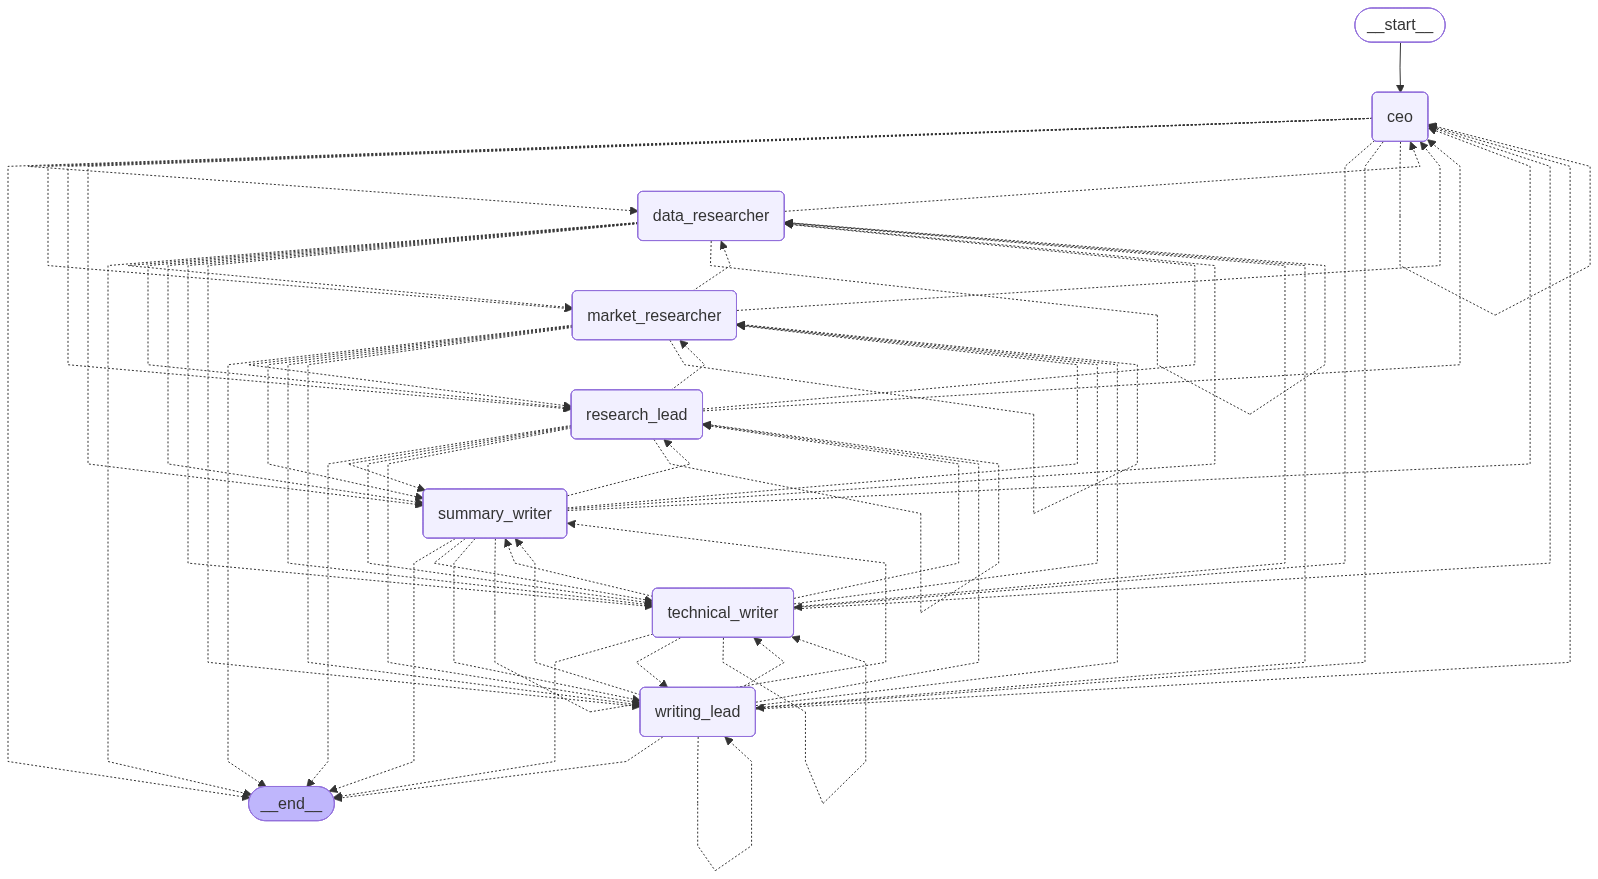

In [23]:
workflow = StateGraph(HierarchicalState)

# Add nodes
workflow.add_node("ceo", ceo_agent)
workflow.add_node("research_lead", research_lead_agent)
workflow.add_node("data_researcher", data_researcher)
workflow.add_node("market_researcher", market_researcher)
workflow.add_node("writing_lead", writing_lead_agent)
workflow.add_node("technical_writer", technical_writer)
workflow.add_node("summary_writer", summary_writer)

# Set entry point
workflow.set_entry_point("ceo")

# Explicit routing map (THIS IS THE FIX)
routing_map = {
    "ceo": "ceo",
    "research_lead": "research_lead",
    "data_researcher": "data_researcher",
    "market_researcher": "market_researcher",
    "writing_lead": "writing_lead",
    "technical_writer": "technical_writer",
    "summary_writer": "summary_writer",
    END: END,
}

# Add conditional edges with explicit destinations
for node in [
    "ceo",
    "research_lead",
    "data_researcher",
    "market_researcher",
    "writing_lead",
    "technical_writer",
    "summary_writer",
]:
    workflow.add_conditional_edges(
        node,
        router,
        routing_map,
    )

# Compile workflow
final_workflow = workflow.compile()
final_workflow

In [24]:
final_workflow.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")],
    "current_task": "Benefits and risks of AI in healthcare",
    "task_complete": False
})


{'messages': [HumanMessage(content='What are the benefits and risks of AI in healthcare?', additional_kwargs={}, response_metadata={}, id='1ce8b6f1-1943-45e1-b652-d6e78a7f6d86'),
  AIMessage(content='CEO: Assigning task to Research Team.', additional_kwargs={}, response_metadata={}, id='c9a0a793-056b-4c77-adbb-b0abd7a437be'),
  AIMessage(content='Research Lead: Assigning researcher.', additional_kwargs={}, response_metadata={}, id='d53f1b8b-4397-431f-9489-54a6e70ad81d'),
  AIMessage(content='Market Research completed.', additional_kwargs={}, response_metadata={}, id='da72bf20-2d19-4088-8462-7eeea72253dc'),
  AIMessage(content='Research Lead: Assigning researcher.', additional_kwargs={}, response_metadata={}, id='bdb5a4a0-e40d-4929-847d-dff4da06e728'),
  AIMessage(content='Data Research completed.', additional_kwargs={}, response_metadata={}, id='32934b66-41a7-4432-9952-1eeb27a7b84e'),
  AIMessage(content='Research Lead: Assigning researcher.', additional_kwargs={}, response_metadata={}

HIERARCHICAL MULTI-AGENT WORKFLOW

User Task
   ↓
CEO Agent (Top-level Supervisor)
   ↓
Research Lead ─────────── Writing Lead
   ↓                         ↓
Market Researcher        Technical Writer
Data Researcher          Summary Writer
   ↑                         ↑
   └────────── Router (state-based) ──────────┘
                      ↓
                     END


HIERARCHICAL MULTI-AGENT SYSTEM – COMPONENT EXPLANATION

1. Shared State (HierarchicalState)
- Acts as a global memory shared across all agents.
- Stores:
  • Messages and task context
  • Research outputs (market_data, research_data)
  • Writing outputs (technical_report, summary_report, final_report)
  • Routing control (next_agent)
  • Completion flag (task_complete)
- Enables stateful, multi-level coordination across agents.

2. CEO Agent (Top-level Supervisor)
- Oversees the entire workflow.
- Decides which team should work next:
  • Research Team
  • Writing Team
  • End workflow
- Writes the routing decision to `next_agent`.
- Key role: Strategic orchestration, not execution.

3. Research Lead (Mid-level Supervisor)
- Manages research sub-agents.
- Delegates tasks to:
  • Market Researcher
  • Data Researcher
- Ensures all required research is completed before returning control to the CEO.
- Key role: Coordination within the research team.

4. Research Sub-Agents (Leaf Agents)
- Market Researcher:
  • Gathers market trends, competitors, and real-world examples.
  • Writes output to `market_data`.
- Data Researcher:
  • Collects technical, statistical, and factual information.
  • Writes output to `research_data`.
- Key role: Execution only (no decision-making).

5. Writing Lead (Mid-level Supervisor)
- Coordinates writing sub-agents.
- Assigns:
  • Technical Writer
  • Summary Writer
- Assembles the final report once all writing tasks are complete.
- Sets `task_complete = True` and routes execution to end.
- Key role: Final aggregation and termination control.

6. Writing Sub-Agents (Leaf Agents)
- Technical Writer:
  • Produces a detailed technical report.
  • Writes output to `technical_report`.
- Summary Writer:
  • Generates an executive summary.
  • Writes output to `summary_report`.
- Key role: Content generation only.

7. Router
- Deterministic control mechanism.
- Routes execution based on:
  • `next_agent`
  • `task_complete`
- Ensures:
  • No infinite loops
  • No LLM-hallucinated control flow
  • Clean termination at END.

8. LangGraph Workflow
- Models the system as a dynamic execution graph.
- Each agent is represented as a node.
- Conditional edges enable hierarchical routing.
- Execution continues until the Writing Lead signals completion.

KEY IDEA
- Decision-making is distributed hierarchically:
  • CEO decides which team works.
  • Team leads decide which agent works.
  • Leaf agents execute tasks.
  • Router enforces deterministic control flow.
- This mirrors real organizational hierarchies and enables scalable,
  maintainable, and production-grade agent systems.
